# Clasificación de Noticias Usando RNNs y LSTMs

## **Estudiante**: Luz Angela Rojas Prieto

### **Propósito de aprendizaje**

#### Adquirir habilidades prácticas en el preprocesamiento de datos textuales y en la implementación de modelos avanzados de RNN y LSTM para la clasificación de noticias en categorías especializadas como deportes, cultura, economía y justicia. Al finalizar, los estudiantes habrán desarrollado la capacidad de construir, entrenar y evaluar estos modelos, así como de comparar su rendimiento de manera crítica.

## **Ejercicio** 1.

**Carga y Exploración de Datos**

**Objetivo:** Familiarizarse con el conjunto de datos y comprender la distribución de las categorías.  
**Acciones:**  
Cargar el archivo Noticias.xlsx que contiene las noticias.  
Explorar la distribución de la columna Etiqueta para ver cuántas noticias pertenecen a cada categoría.  
Visualizar esta distribución mediante gráficos para identificar las categorías más frecuentes.  
Contexto: La columna Etiqueta en el conjunto de datos contiene categorías, algunas no especializadas o no tienen un enfoque específico (por ejemplo, "archivo"). Para esta actividad, nos centraremos en noticias de las categorías especializadas: deportes, cultura, economía y justicia. Estas categorías son relevantes porque representan temas con un enfoque claro y específico, lo que hace que la clasificación sea más útil y aplicable en el análisis de noticias.

#### Cargar el archivo Noticias.xlsx que contiene las noticias.

In [2]:
# Importar las bibliotecas necesarias
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
import string
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

In [3]:
# Descargar recursos de NLTK
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Ruta al archivo
ruta_archivo = '/content/drive/My Drive/Colab Notebooks/Noticias.xlsx'

# Leer el archivo Excel
data = pd.read_excel(ruta_archivo)

# Mostrar las primeras filas
data.head()

,Columna1,Enlaces,Título,info,contenido,Etiqueta
0,0,https://www.eltiempo.com/agresion-contra-un-op...,Operador de grúa quedó inconsciente tras agres...,El conductor de una moto le lanzó el casco y p...,Las autoridades están buscando al conductor de...,colombia
1,1,https://www.eltiempo.com/archivo/documento/CMS...,"Usaquén, primera en infracciones por mal parqueo",La localidad ocupa el primer lugar en comparen...,"""Los andenes son para los peatones"", reclama e...",archivo
2,2,https://www.eltiempo.com/archivo/documento/CMS...,'Me atracaron y vi un arma que me heló la sang...,Un ciudadano relata cómo cuatro hombres lo rob...,A las 7 de la noche me había quedado de encont...,archivo
3,3,https://www.eltiempo.com/archivo/documento/CMS...,"Escoltas mal estacionados, dolor de cabeza de ...",Las zonas de restaurantes se convierten en par...,Atravesados. Eso es lo que se les pasa por la ...,archivo
4,4,https://www.eltiempo.com/archivo/documento/CMS...,Radicado primer proyecto que autorizaría union...,"El representante de 'la U', Miguel Gómez, dijo...",“Estamos proponiendo la figura de un contrato ...,archivo


#### Explorar la distribución de la columna Etiqueta para ver cuántas noticias pertenecen a cada categoría.

In [6]:
# Información sobre el dataset (tipos de datos, valores no nulos, etc.)
print(data.info())

# Estadísticas descriptivas (numéricas)
print(data.describe())

# Dimensiones del dataset (filas y columnas)
print(f"Filas: {data.shape[0]}, Columnas: {data.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Columna1   14396 non-null  int64 
 1   Enlaces    14396 non-null  object
 2   Título     14378 non-null  object
 3   info       11483 non-null  object
 4   contenido  13738 non-null  object
 5   Etiqueta   14396 non-null  object
dtypes: int64(1), object(5)
memory usage: 674.9+ KB
None
           Columna1
count  14396.000000
mean    7197.500000
std     4155.911573
min        0.000000
25%     3598.750000
50%     7197.500000
75%    10796.250000
max    14395.000000
Filas: 14396, Columnas: 6


In [7]:
# Contar la cantidad de noticias por categoría en la columna 'Etiqueta'
distribucion_etiquetas = data['Etiqueta'].value_counts()

# Mostrar la distribución
print(distribucion_etiquetas)

Etiqueta
archivo                 9187
colombia                 934
deportes                 727
opinion                  532
mundo                    446
cultura                  430
economia                 367
justicia                 343
bogota                   311
vida                     268
politica                 252
tecnosfera               214
salud                    106
historias-el-tiempo       57
mundial                   47
contenido-comercial       34
elecciones                33
unidad-investigativa      27
podcast                   20
foro-w                    18
bocas                     15
carrusel                   8
datos                      7
lecturas-dominicales       6
mas-contenido              4
especiales                 3
Name: count, dtype: int64


#### Visualizar esta distribución mediante gráficos para identificar las categorías más frecuentes.


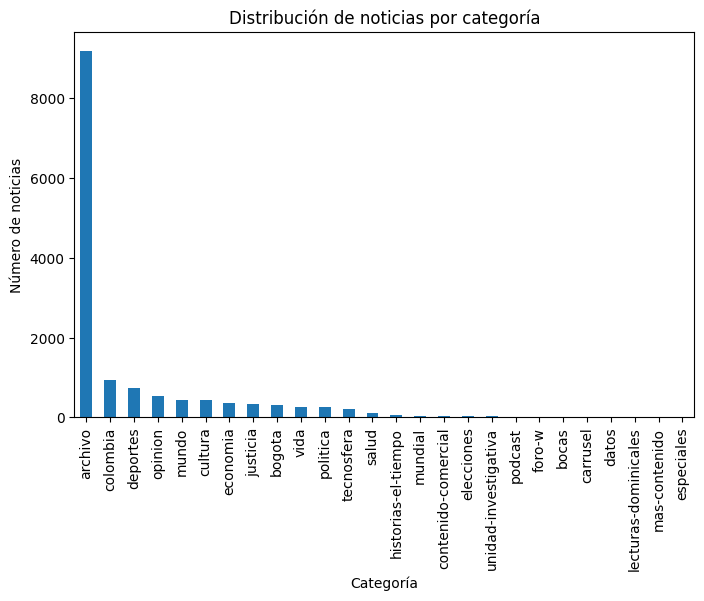

In [8]:
# Graficar la distribución
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
distribucion_etiquetas.plot(kind='bar')
plt.title('Distribución de noticias por categoría')
plt.xlabel('Categoría')
plt.ylabel('Número de noticias')
plt.xticks(rotation=90)
plt.show()

## **Ejercicio** 2.

**Filtrado de Datos**

**Objetivo:** Limitar el conjunto de datos a las categorías relevantes para garantizar que el modelo se entrene y evalúe en temas especializados.  
**Acciones:**  
Excluir las noticias que pertenecen a la categoría "archivo" y cualquier otra que no esté en las categorías de deportes, cultura, economía y justicia.  
Asegurarse de que el conjunto de datos resultante tenga una distribución equilibrada para estas categorías, en la medida de lo posible.  
Contexto: Es importante filtrar los datos para enfocarnos en temas especializados porque algunas categorías pueden tener un discurso amplio y no se tratan de un tema especializado. Esto ayuda a mejorar la precisión del modelo al enfocarse en categorías bien definidas.

#### Excluir las noticias que pertenecen a la categoría "archivo" y cualquier otra que no esté en las categorías de deportes, cultura, economía y justicia.

In [9]:
# Lista de categorías que queremos conservar
categorias_permitidas = ['deportes', 'cultura', 'economia', 'justicia']

# Filtrar el DataFrame excluyendo "archivo" y manteniendo solo las categorías permitidas
data_filtrada = data[data['Etiqueta'].isin(categorias_permitidas)]

# Verificar la distribución después del filtrado
print(data_filtrada['Etiqueta'].value_counts())

# Mostrar las primeras filas del nuevo DataFrame
data_filtrada.sample(5)


Etiqueta
deportes    727
cultura     430
economia    367
justicia    343
Name: count, dtype: int64


,Columna1,Enlaces,Título,info,contenido,Etiqueta
10697,10697,https://www.eltiempo.com/cultura/gente/consejo...,"Una mascota es cuestión de afecto, no de raza:...",NaN,Miedo 11:19 p.m. Ejercite su mente en la cuare...,cultura
11185,11185,https://www.eltiempo.com/deportes/futbol-colom...,Junior quiere ratificar el liderato en el clás...,El juego adelantado de la fecha 13 se jugará e...,Serán cuatro los cambios que tendrá Junior en ...,deportes
10579,10579,https://www.eltiempo.com/cultura/cine-y-tv/est...,"Se estrena 'Ready Player One', de Steven Spiel...",La película y el libro son un viaje nostálgico...,Esta nota no es apta para quienes no jugaron P...,cultura
12145,12145,https://www.eltiempo.com/justicia/conflicto-y-...,Qué quiso decir Iván Márquez con ‘ha comenzado...,Expertos explican la importancia de esta zona ...,"Por medio de un video , un grupo de comandante...",justicia
11250,11250,https://www.eltiempo.com/deportes/futbol-inter...,Atalanta adquiere los derechos del colombiano ...,El club hizo efectiva la opción de compra que ...,El Atalanta adquirió los derechos del delanter...,deportes


In [10]:
# Eliminar filas con nulos en columnas específicas
data_limpia = data_filtrada.dropna(subset=['Título', 'contenido','info', 'Etiqueta'])
print(f"Dataset después de eliminar nulos: {data_limpia.shape}")

Dataset después de eliminar nulos: (1820, 6)


In [11]:
# Información sobre el dataset (tipos de datos, valores no nulos, etc.)
print(data_limpia.info())

# Estadísticas descriptivas (numéricas)
print(data_limpia.describe())

# Dimensiones del dataset (filas y columnas)
print(f"Filas: {data_limpia.shape[0]}, Columnas: {data_limpia.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
Index: 1820 entries, 10487 to 12471
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Columna1   1820 non-null   int64 
 1   Enlaces    1820 non-null   object
 2   Título     1820 non-null   object
 3   info       1820 non-null   object
 4   contenido  1820 non-null   object
 5   Etiqueta   1820 non-null   object
dtypes: int64(1), object(5)
memory usage: 99.5+ KB
None
           Columna1
count   1820.000000
mean   11452.361538
std      571.030464
min    10487.000000
25%    10968.750000
50%    11435.500000
75%    11899.250000
max    12471.000000
Filas: 1820, Columnas: 6


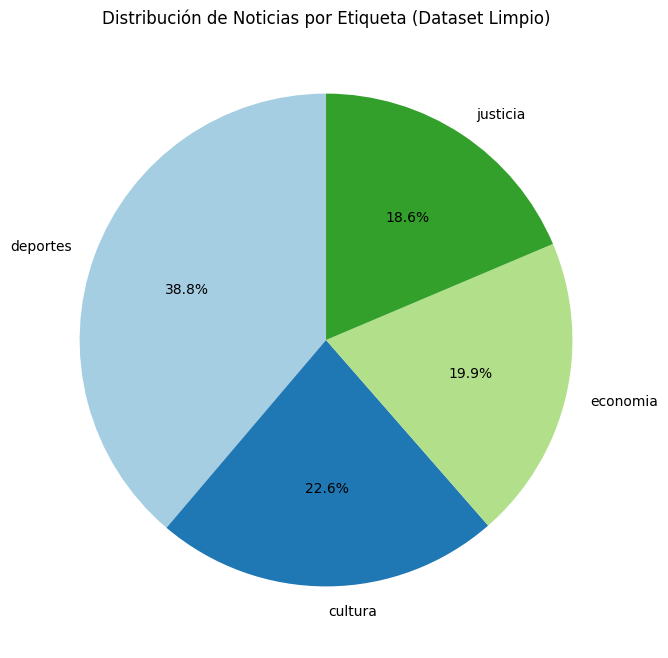

In [12]:
# Crear un gráfico de torta para las etiquetas en el dataset limpio
etiquetas = data_limpia['Etiqueta'].value_counts()

# Generar el gráfico de torta
plt.figure(figsize=(8, 8))
etiquetas.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribución de Noticias por Etiqueta (Dataset Limpio)')
plt.ylabel('')  # Eliminar el texto del eje Y para un gráfico más limpio
plt.show()

## **Ejercicio** 3.

**Preprocesamiento de Texto**  

**Objetivo:** Preparar los datos textuales para el entrenamiento del modelo.  
**Acciones:**  
Convertir todo el texto a minúsculas para uniformidad.  
Eliminar puntuación y números para reducir el ruido en los datos.  
Eliminar palabras comunes (stop words) que no aportan significado específico al análisis.  
Tokenizar el texto, es decir, dividir el texto en palabras individuales.  
Aplicar padding a las secuencias de palabras para que todas tengan la misma longitud, facilitando el procesamiento por las redes neuronales.

#### Preprocesamiento

In [13]:
import re
import string
from nltk.corpus import stopwords
import nltk

# Descargar recursos necesarios de NLTK
nltk.download('stopwords')

# Definir las stop words en español
stop_words = set(stopwords.words('spanish'))

# Función para eliminar tildes y preservar la letra 'ñ'
def remove_accents(text):
    """
    Elimina las tildes del texto pero preserva la letra 'ñ'.
    """
    tildes = str.maketrans('áéíóúüÁÉÍÓÚÜ', 'aeiouuAEIOUU')
    text = text.translate(tildes)
    return text

# Función completa de preprocesamiento
def preprocess_text(text):
    """
    Preprocesamiento del texto:
    - Convierte el texto a minúsculas.
    - Elimina las tildes.
    - Elimina guiones y puntuación.
    - Elimina los números.
    - Elimina los espacios en blanco adicionales.
    - Elimina las stop words.
    """
    # Convertir a minúsculas
    text = text.lower()
    # Quitar tildes
    text = remove_accents(text)
    # Eliminar guiones (normales y largos) y puntuación
    text = re.sub(r'[-–—]', '', text)  # Elimina guiones de cualquier tipo
    text = text.translate(str.maketrans('', '', string.punctuation + '‘’“”'))
    # Eliminar números
    text = re.sub(r'\d+', '', text)
    # Eliminar espacios en blanco adicionales
    text = ' '.join(text.split())
    # Eliminar stop words
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Aplicar preprocesamiento
data_limpia['contenido_preprocesado'] = data_limpia['contenido'].apply(preprocess_text)

# Verificar los resultados
data_limpia[['contenido', 'contenido_preprocesado']].sample(25)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-13-f56da2aad36d>:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_limpia['contenido_preprocesado'] = data_limpia['contenido'].apply(preprocess_text)


,contenido,contenido_preprocesado
11670,Las fusiones y adquisiciones internacionales y...,fusiones adquisiciones internacionales locales...
10979,"El ciclista colombiano Rigoberto Urán, del EF ...",ciclista colombiano rigoberto uran ef pro cycl...
12360,El Tribunal Administrativo de Cundinamarca adm...,tribunal administrativo cundinamarca admitio e...
12281,El juzgado tercero penal municipal de Medellín...,juzgado tercero penal municipal medellin decid...
11476,"LA FIFA, en reunión del buró de su Consejo, ac...",fifa reunion buro consejo acordo serie propues...
11672,Tras crecer en el 2018 un 40 por ciento su pro...,tras crecer ciento produccion partir segundo s...
11618,El tenista colombiano Daniel Galán venció al f...,tenista colombiano daniel galan vencio frances...
11371,Diego Maradona fue internado este viernes por ...,diego maradona internado viernes sangrado esto...
11930,El pliego de peticiones que aún sigue en discu...,pliego peticiones aun sigue discusion pilotos ...
11051,"Tras su contundente victoria sobre Ecuador, Ur...",tras contundente victoria ecuador uruguay alis...


#### Tokenizar el texto, es decir, dividir el texto en palabras individuales.

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Inicializar el Tokenizer
tokenizer = Tokenizer()

# Ajustar el Tokenizer al texto preprocesado en data_limpia
tokenizer.fit_on_texts(data_limpia['contenido_preprocesado'])

# Convertir el texto en secuencias numéricas
sequences = tokenizer.texts_to_sequences(data_limpia['contenido_preprocesado'])

# Obtener el índice de palabras
word_index = tokenizer.word_index
print(f"Cantidad de palabras únicas en el vocabulario: {len(word_index)}")

# Aplicar padding a las secuencias
max_len =100   # Longitud máxima de las secuencias
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

# Añadir las secuencias con padding a data_limpia
data_limpia['padded_sequences'] = list(padded_sequences)

# Mostrar algunas secuencias preprocesadas con padding
print("Secuencias con padding:")
data_limpia[['contenido_preprocesado', 'padded_sequences']].head()

Cantidad de palabras únicas en el vocabulario: 47915
Secuencias con padding:


<ipython-input-17-d3e322d5546e>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_limpia['padded_sequences'] = list(padded_sequences)


,contenido_preprocesado,padded_sequences
10487,citas crimenes violencia sexual cometidos inte...,"[6371, 10323, 1543, 3434, 1397, 4439, 1232, 19..."
10488,motivo celebracion años enseñanza danza orient...,"[67, 49, 90, 327, 218, 1734, 26911, 9302, 184,..."
10489,cuadro busto mujer artista español pablo picas...,"[19686, 1850, 7836, 2301, 4642, 83, 73, 1399, ..."
10490,carnaval artes organizado barranquilla fundaci...,"[19691, 842, 26924, 2296, 26925, 3347, 768, 36..."
10491,louise du toit filosofa doctor denis mukwege p...,"[26931, 225, 1806, 5996, 2103, 301, 860, 56, 4..."


## **Ejercicio** 4.

**División del Conjunto de Datos**  

**Objetivo:** Crear conjuntos de datos de entrenamiento y validación para evaluar el modelo.  
**Acciones:**
Dividir el conjunto de datos preprocesado en dos partes: uno para entrenar el modelo y otro para validarlo.  
Asegurarse de que la división sea aleatoria, pero que mantenga una proporción similar de las categorías en ambos conjuntos.  

In [23]:
data_limpia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1820 entries, 10487 to 12471
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Columna1                1820 non-null   int64 
 1   Enlaces                 1820 non-null   object
 2   Título                  1820 non-null   object
 3   info                    1820 non-null   object
 4   contenido               1820 non-null   object
 5   Etiqueta                1820 non-null   object
 6   contenido_preprocesado  1820 non-null   object
 7   padded_sequences        1820 non-null   object
dtypes: int64(1), object(7)
memory usage: 128.0+ KB


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Codificación de etiquetas
label_encoder = LabelEncoder()
data_limpia['Etiqueta_codificada'] = label_encoder.fit_transform(data_limpia['Etiqueta'])

# División del conjunto de datos
X_train, X_val, y_train, y_val = train_test_split(padded_sequences, data_limpia['Etiqueta_codificada'], test_size=0.2, random_state=42)

# Mostrar tamaño de los conjuntos de datos
len(X_train), len(X_val)

(1456, 364)

## **Ejercicio** 5.

**Implementación de un Modelo RNN**  

**Objetivo:** Construir y entrenar un modelo RNN para clasificar las noticias.  
**Acciones:**  
Definir la arquitectura del modelo RNN, incluyendo capas de embedding y capas recurrentes.  
Configurar los hiperparámetros del modelo, como el tamaño del embedding y el número de unidades recurrentes.  
Entrenar el modelo utilizando el conjunto de datos de entrenamiento y evaluar su rendimiento en el conjunto de validación.  

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.3067 - loss: 1.3909 - val_accuracy: 0.3626 - val_loss: 1.3396
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.4114 - loss: 1.2845 - val_accuracy: 0.4066 - val_loss: 1.2754
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.6254 - loss: 1.0394 - val_accuracy: 0.4451 - val_loss: 1.2468
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.8082 - loss: 0.7907 - val_accuracy: 0.4313 - val_loss: 1.2875
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.9129 - loss: 0.5894 - val_accuracy: 0.3929 - val_loss: 1.3287
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.9592 - loss: 0.4510 - val_accuracy: 0.3929 - val_loss: 1.4870


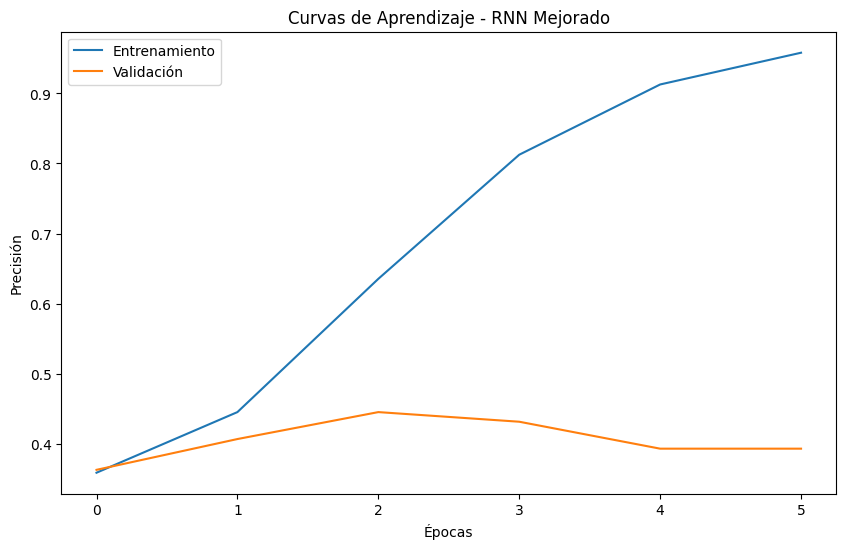

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4167 - loss: 1.2540
Precisión en Validación: 0.45


In [40]:
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

# Construcción del modelo RNN
model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=len(word_index) + 1, output_dim=128, input_length=max_len))
model_rnn.add(SimpleRNN(units=64, return_sequences=False))
model_rnn.add(Dropout(0.2))  # Regularización para prevenir sobreajuste
model_rnn.add(Dense(units=len(np.unique(y_train)), activation='softmax'))  # Corregido el número de salidas

# Compilación del modelo
optimizer = Adam(learning_rate=0.0001)  # Aprendizaje más lento para mayor estabilidad
model_rnn.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Early Stopping para detener el entrenamiento automáticamente
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

# Entrenamiento del modelo
history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping]  # Early Stopping activado
)

# Visualización de resultados del modelo RNN
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['accuracy'], label='Entrenamiento')
plt.plot(history_rnn.history['val_accuracy'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Curvas de Aprendizaje - RNN Mejorado')
plt.show()

# Evaluación final
loss, accuracy = model_rnn.evaluate(X_val, y_val)
print(f"Precisión en Validación: {accuracy:.2f}")


## **Ejercicio** 6.

**Implementación de un Modelo LSTM**  

**Objetivo:** Construir y entrenar un modelo LSTM para clasificar las noticias.  
**Acciones:**  
Definir la arquitectura del modelo LSTM, que incluye celdas LSTM diseñadas para manejar dependencias a largo plazo más eficientemente.  
Configurar los hiperparámetros del modelo, similar al proceso del modelo RNN.  
Entrenar el modelo LSTM y evaluar su rendimiento utilizando los mismos conjuntos de datos.  

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 423ms/step - accuracy: 0.3366 - loss: 1.3816 - val_accuracy: 0.3709 - val_loss: 1.3659
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 336ms/step - accuracy: 0.3832 - loss: 1.3506 - val_accuracy: 0.3709 - val_loss: 1.3334
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 361ms/step - accuracy: 0.3962 - loss: 1.2629 - val_accuracy: 0.3901 - val_loss: 1.0371
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 336ms/step - accuracy: 0.5850 - loss: 0.9078 - val_accuracy: 0.5440 - val_loss: 0.8869
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 336ms/step - accuracy: 0.6497 - loss: 0.7690 - val_accuracy: 0.5687 - val_loss: 0.8327
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 334ms/step - accuracy: 0.6091 - loss: 0.7515 - val_accuracy: 0.5769 - val_loss: 0.8022
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.6044 - loss: 0.7477 - val_accuracy: 0.5769 - val_loss: 0.7825
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 336ms/step - accuracy: 0.6233 - loss: 0.7014 - val_accu

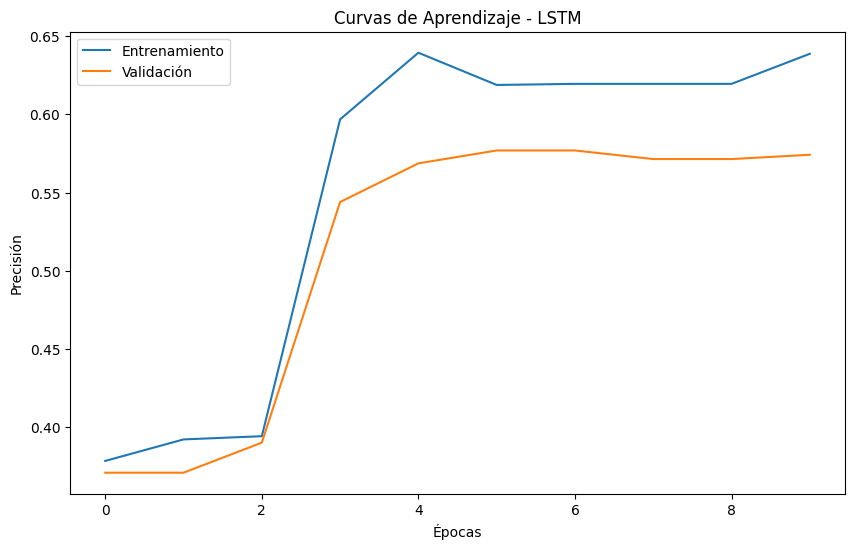

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

# Modelo LSTM
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=len(word_index) + 1, output_dim=128, input_length=max_len))
model_lstm.add(Bidirectional(LSTM(units=64, return_sequences=True)))
model_lstm.add(Dropout(0.2))  # Regularización moderada
model_lstm.add(Bidirectional(LSTM(units=32)))
model_lstm.add(Dense(units=len(np.unique(y_train)), activation='softmax'))

# Compilación del modelo
optimizer = Adam(learning_rate=0.0001)  # Tasa de aprendizaje ajustada
model_lstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenamiento
history_lstm = model_lstm.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

# Visualización de resultados
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['accuracy'], label='Entrenamiento')
plt.plot(history_lstm.history['val_accuracy'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Curvas de Aprendizaje - LSTM')
plt.show()


## **Ejercicio** 7.

**Comparación de Resultados**  

**Objetivo:** Evaluar y comparar el rendimiento de los modelos RNN y LSTM.  
**Acciones:**  
Calcular y comparar métricas de rendimiento como precisión, recall y F1-score para ambos modelos.  
Visualizar las curvas de aprendizaje y los resultados de validación para entender mejor cómo se desempeñan los modelos en las tareas de clasificación.  
Comparar los modelos permite entender las fortalezas y debilidades de cada enfoque, proporcionando información valiosa para elegir el modelo más adecuado para tareas específicas de clasificación de texto.  
Documentar estos resultados de forma asertiva en el cuaderno y en el informe.

In [42]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predicciones para los modelos
y_pred_rnn = np.argmax(model_rnn.predict(X_val), axis=1)
y_pred_lstm = np.argmax(model_lstm.predict(X_val), axis=1)

# Reporte de clasificación para RNN
print("Resultados para RNN:")
print(classification_report(y_val, y_pred_rnn, target_names=label_encoder.classes_))

# Reporte de clasificación para LSTM
print("Resultados para LSTM:")
print(classification_report(y_val, y_pred_lstm, target_names=label_encoder.classes_))

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step
Resultados para RNN:
              precision    recall  f1-score   support

     cultura       0.57      0.49      0.53        79
    deportes       0.54      0.63      0.58       135
    economia       0.59      0.56      0.58        78
    justicia       0.47      0.42      0.44        72

    accuracy                           0.54       364
   macro avg       0.54      0.53      0.53       364
weighted avg       0.54      0.54      0.54       364

Resultados para LSTM:
              precision    recall  f1-score   support

     cultura       0.34      0.97      0.50        79
    deportes       0.97      0.98      0.97       135
    economia       0.00      0.00      0.00        78
    justicia       0.00      0.00      0.00        72

    accuracy                           0.57       364
   macro avg       0.33      0.49      0.37       364
weighted avg       0.43      0.57      0.47       364



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Ejercicio** 8.

**Evaluación y Conclusiones**

**Objetivo:** Sintetizar los hallazgos y discutir las implicaciones prácticas.  
**Acciones:**  
Documentar los resultados obtenidos en un informe detallado, incluyendo gráficos y análisis de las métricas de rendimiento.  
Discutir las implicaciones de los resultados para aplicaciones prácticas de NLP, como la automatización de la clasificación de noticias en sistemas de recomendación o análisis de medios.  
Proponer posibles mejoras y futuras direcciones de investigación, como la exploración de arquitecturas híbridas o la integración de mecanismos de atención.

##### En el análisis de los modelos RNN y LSTM, se observó que ambos presentaron limitaciones en su desempeño. El modelo RNN logró una precisión del 54% y un F1-Score de 0.53 en promedio, pero en clases menos representadas no realizo una clasificación adecuada, como en la etiqueta "justicia", con bajos resultados en precisión y en recall. Por otro lado, el modelo LSTM alcanzó una precisión del 57%, pero en categorias como "deportes" y "cultura" mostro sesgo, ya que tuvo una precisión muy alta, mientras que en "economía" y "justicia", no realizó predicciones correctas, resultando en un F1-Score de 0.47.

##### a pesar de que el LSTM tiene potencial para captar relaciones más complejas, se necesitaba realizar ajustes adicionales en los modelos. y no se implementaron técnicas importantes como el reequilibrio de las clases mediante oversampling o SMOTE, el uso de embeddings preentrenados (como GloVe o Word2Vec) o ajustes más avanzados en la arquitectura del LSTM, como agregar capas adicionales o mejor regularización para prevenir el sobreajuste. 😢
